In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Experiment6_Placement_Dataset.csv to Experiment6_Placement_Dataset.csv


In [3]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (50000, 32)
   Age  Gender       City Stream  CGPA CGPA_Tier  AptitudeTestScore  \
0   23    Male    Chennai    ECE  8.52       Low          87.736291   
1   24    Male  Bangalore    CSE  6.99       Low          44.816688   
2   22    Male  Hyderabad   MECH  6.94       Low          49.757072   
3   24  Female     Mumbai    EEE  7.75    Medium          66.141468   
4   24    Male  Hyderabad    ECE  6.76    Medium          68.036969   

   CodingTestScore  SoftSkillsRating  MockInterviewScore  ...  StudyHours  \
0        34.998290          6.683858           71.897497  ...    6.102519   
1        84.101821          6.986297           48.549582  ...    5.081101   
2        72.445659          6.478156          100.339073  ...    2.771027   
3        67.292036          6.886553           38.839943  ...    1.800227   
4        67.496071          6.242697           89.927046  ...    6.857750   

   Extracurriculars  VolunteerWork  WorkExperience  PortfolioScore  \
0            

In [4]:
print(df.columns.tolist())

print("\nPlacementStatus distribution:")
print(df["PlacementStatus"].value_counts())

['Age', 'Gender', 'City', 'Stream', 'CGPA', 'CGPA_Tier', 'AptitudeTestScore', 'CodingTestScore', 'SoftSkillsRating', 'MockInterviewScore', 'Workshops', 'Internships', 'Projects', 'Certifications', 'Hackathons', 'CommunicationScore', 'TechnicalSkillsScore', 'ProblemSolvingScore', 'LeadershipScore', 'TeamworkScore', 'Attendance', 'Backlogs', 'StudyHours', 'Extracurriculars', 'VolunteerWork', 'WorkExperience', 'PortfolioScore', 'ResumeScore', 'InterviewScore', 'EnglishScore', 'TechnicalInterviewScore', 'PlacementStatus']

PlacementStatus distribution:
PlacementStatus
1    34627
0    15373
Name: count, dtype: int64


In [5]:
target = "PlacementStatus"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (50000, 31)
y shape: (50000,)

Target distribution:
PlacementStatus
1    34627
0    15373
Name: count, dtype: int64


In [6]:
target = "PlacementStatus"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (50000, 31)
y shape: (50000,)

Target distribution:
PlacementStatus
1    34627
0    15373
Name: count, dtype: int64


In [7]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded X shape:", X.shape)

Encoded X shape: (50000, 38)


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (40000, 38)
X_val: (10000, 38)
y_train: (40000,)
y_val: (10000,)


In [9]:
print("Missing values in X:")
print(X.isna().sum().sort_values(ascending=False).head(20))

print("\nTotal missing values:", X.isna().sum().sum())

Missing values in X:
MockInterviewScore      4957
Workshops               4488
AptitudeTestScore       4029
SoftSkillsRating        3526
CodingTestScore         2976
CGPA                       0
Age                        0
Internships                0
Projects                   0
Certifications             0
Hackathons                 0
CommunicationScore         0
TechnicalSkillsScore       0
ProblemSolvingScore        0
LeadershipScore            0
TeamworkScore              0
Attendance                 0
Backlogs                   0
StudyHours                 0
Extracurriculars           0
dtype: int64

Total missing values: 19976


In [10]:
X = X.replace([np.inf, -np.inf], np.nan)

print(
    "Missing values after replacing infinity:",
    X.isna().sum().sum()
)

Missing values after replacing infinity: 19976


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (40000, 38)
X_val: (10000, 38)


In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

print(
    "Training missing values:",
    np.isnan(X_train_imputed).sum()
)

print(
    "Validation missing values:",
    np.isnan(X_val_imputed).sum()
)

Training missing values: 0
Validation missing values: 0


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)

X_train_scaled: (40000, 38)
X_val_scaled: (10000, 38)


In [14]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

print(C_values)

[0.001, 0.01, 0.1, 1, 10, 100]


In [16]:
def compare_regularisation(X_train, y_train, X_val, y_val, C_values):

    results = []

    for C in C_values:

        # LASSO - L1
        lasso = LogisticRegression(
            penalty="l1",
            C=C,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        )

        lasso.fit(X_train, y_train)

        lasso_pred = lasso.predict(X_val)

        lasso_acc = accuracy_score(
            y_val,
            lasso_pred
        )

        lasso_nonzero = np.sum(
            np.abs(lasso.coef_) > 1e-6
        )


        # RIDGE - L2
        ridge = LogisticRegression(
            penalty="l2",
            C=C,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        )

        ridge.fit(X_train, y_train)

        ridge_pred = ridge.predict(X_val)

        ridge_acc = accuracy_score(
            y_val,
            ridge_pred
        )

        ridge_nonzero = np.sum(
            np.abs(ridge.coef_) > 1e-6
        )


        # ELASTIC NET - L1 + L2
        elastic = LogisticRegression(
            penalty="elasticnet",
            C=C,
            l1_ratio=0.5,
            solver="saga",
            max_iter=5000,
            random_state=42
        )

        elastic.fit(X_train, y_train)

        elastic_pred = elastic.predict(X_val)

        elastic_acc = accuracy_score(
            y_val,
            elastic_pred
        )


        results.append({
            "C": C,
            "Lasso_val_acc": lasso_acc,
            "Ridge_val_acc": ridge_acc,
            "ElasticNet_val_acc": elastic_acc,
            "Lasso_nonzero": lasso_nonzero,
            "Ridge_nonzero": ridge_nonzero
        })

    return pd.DataFrame(results)

In [17]:
results_df = compare_regularisation(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    C_values
)

results_df

,C,Lasso_val_acc,Ridge_val_acc,ElasticNet_val_acc,Lasso_nonzero,Ridge_nonzero
0,0.001,0.9382,0.9655,0.9547,8,38
1,0.010,0.9663,0.9663,0.9668,10,38
2,0.100,0.9663,0.9662,0.9664,29,38
3,1.000,0.9663,0.9663,0.9663,37,38
4,10.000,0.9663,0.9663,0.9663,38,38
5,100.000,0.9663,0.9663,0.9663,38,38


In [18]:
best_lasso = results_df.loc[
    results_df["Lasso_val_acc"].idxmax()
]

print("Best Lasso:")
print(best_lasso)


best_ridge = results_df.loc[
    results_df["Ridge_val_acc"].idxmax()
]

print("\nBest Ridge:")
print(best_ridge)


best_elastic = results_df.loc[
    results_df["ElasticNet_val_acc"].idxmax()
]

print("\nBest Elastic Net:")
print(best_elastic)

Best Lasso:
C                      0.0100
Lasso_val_acc          0.9663
Ridge_val_acc          0.9663
ElasticNet_val_acc     0.9668
Lasso_nonzero         10.0000
Ridge_nonzero         38.0000
Name: 1, dtype: float64

Best Ridge:
C                      0.0100
Lasso_val_acc          0.9663
Ridge_val_acc          0.9663
ElasticNet_val_acc     0.9668
Lasso_nonzero         10.0000
Ridge_nonzero         38.0000
Name: 1, dtype: float64

Best Elastic Net:
C                      0.0100
Lasso_val_acc          0.9663
Ridge_val_acc          0.9663
ElasticNet_val_acc     0.9668
Lasso_nonzero         10.0000
Ridge_nonzero         38.0000
Name: 1, dtype: float64


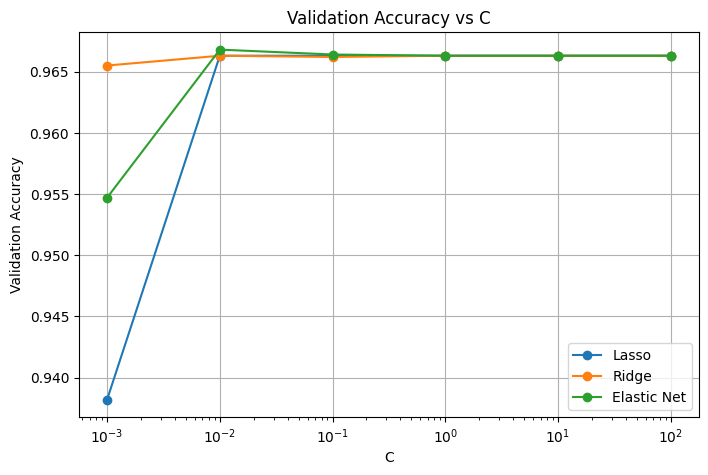

In [19]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    results_df["C"],
    results_df["Lasso_val_acc"],
    marker="o",
    label="Lasso"
)

plt.semilogx(
    results_df["C"],
    results_df["Ridge_val_acc"],
    marker="o",
    label="Ridge"
)

plt.semilogx(
    results_df["C"],
    results_df["ElasticNet_val_acc"],
    marker="o",
    label="Elastic Net"
)

plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs C")
plt.legend()
plt.grid(True)

plt.show()

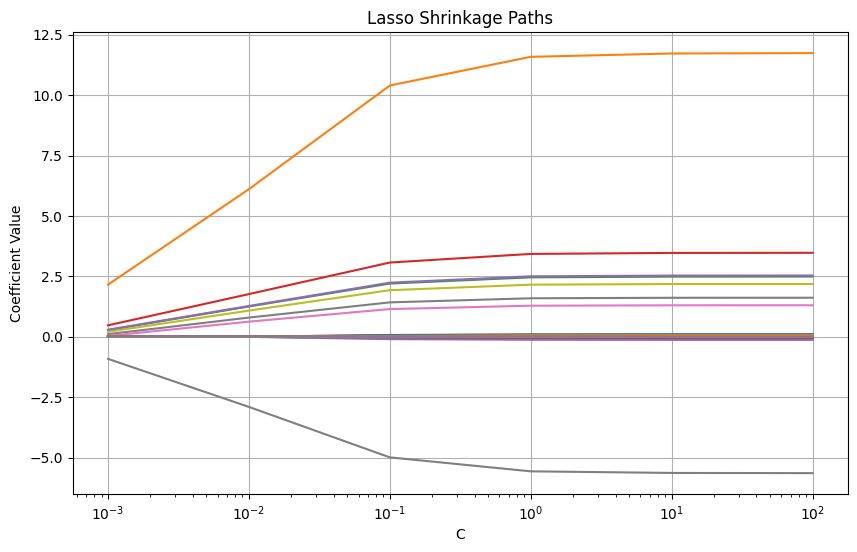

In [20]:
lasso_coefficients = []

for C in C_values:

    model = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    lasso_coefficients.append(model.coef_[0])


lasso_coefficients = np.array(lasso_coefficients)


plt.figure(figsize=(10, 6))

for i in range(lasso_coefficients.shape[1]):

    plt.semilogx(
        C_values,
        lasso_coefficients[:, i]
    )

plt.xlabel("C")
plt.ylabel("Coefficient Value")
plt.title("Lasso Shrinkage Paths")
plt.grid(True)

plt.show()

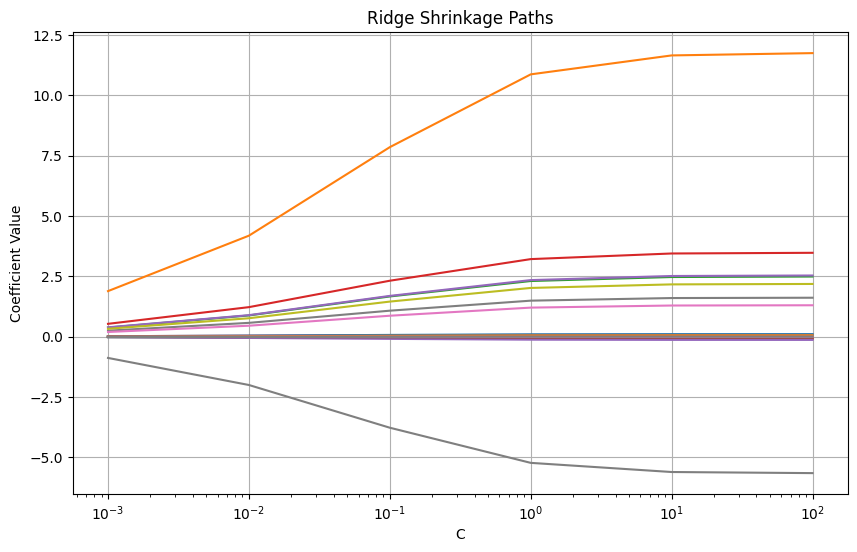

In [21]:
ridge_coefficients = []

for C in C_values:

    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    ridge_coefficients.append(model.coef_[0])


ridge_coefficients = np.array(ridge_coefficients)


plt.figure(figsize=(10, 6))

for i in range(ridge_coefficients.shape[1]):

    plt.semilogx(
        C_values,
        ridge_coefficients[:, i]
    )

plt.xlabel("C")
plt.ylabel("Coefficient Value")
plt.title("Ridge Shrinkage Paths")
plt.grid(True)

plt.show()